# 04. Backtest fuera de muestra

En el notebook 03 la cartera de máximo Sharpe se optimizó con los mismos datos con los que se evaluó, y eso favorece el resultado. Aquí lo pongo a prueba:

1. **Entrenamiento (2016-2019):** estimo rentabilidades y covarianzas y calculo los pesos óptimos.
2. **Prueba (2020-2025):** aplico esos pesos a datos que el optimizador no ha visto y mido el resultado real.

Comparo tres carteras: pesos iguales, mínima varianza y máximo Sharpe. Al final repito el ejercicio con otra partición (entrenamiento 2016-2022, prueba 2023-2025) para ver si las conclusiones dependen de la fecha de corte.

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.portfolio import cartera_min_varianza, cartera_max_sharpe, backtest, resumen_activos

precios = pd.read_csv("../data/precios.csv", index_col="Date", parse_dates=True)
rentabilidades = precios.pct_change().dropna()

tbill = pd.read_csv("../data/DGS3MO.csv", index_col=0, parse_dates=True).iloc[:, 0]
tbill = pd.to_numeric(tbill, errors="coerce")

# Partición temporal: nunca se mezclan los años
entrenamiento = rentabilidades.loc["2016":"2019"]
prueba = rentabilidades.loc["2020":"2025"]

rf_ent = tbill.loc["2016":"2019"].mean() / 100
rf_prueba = tbill.loc["2020":"2025"].mean() / 100

rf_ent, rf_prueba

(np.float64(0.013358058058058057), np.float64(0.028556800000000004))

**Tasa libre de riesgo de cada periodo:** 1,13 % en el entrenamiento (2016-2019) y 2,86 % en la prueba (2020-2025). La de la prueba es intermedia porque mezcla los tipos casi en cero de 2020-2021 con los tipos altos de 2023-2025.

In [2]:
activos = entrenamiento.columns

# Solo uso el periodo de entrenamiento para estimar
mu_ent = entrenamiento.mean().values * 252
cov_ent = entrenamiento.cov().values * 252

carteras = {
    "Pesos iguales": np.repeat(1 / len(activos), len(activos)),
    "Mín. varianza": cartera_min_varianza(cov_ent),
    "Máx. Sharpe": cartera_max_sharpe(cov_ent, mu_ent, rf_ent),
}

pd.DataFrame(carteras, index=activos).round(3)

,Pesos iguales,Mín. varianza,Máx. Sharpe
AGG,0.167,0.913,0.656
EEM,0.167,0.000,0.000
EFA,0.167,0.010,0.000
GLD,0.167,0.000,0.100
SPY,0.167,0.077,0.244
VNQ,0.167,0.000,0.000


Pesos óptimos con los datos de entrenamiento (2016-2019)

El reparto es muy distinto al del notebook 03, calculado con diez años (58,3 % oro y 41,7 % S&P 500): ahora la cartera de máximo Sharpe pone dos tercios en bonos y solo un 10 % en oro. Los pesos óptimos de Markowitz son **muy sensibles al periodo de estimación**.

In [3]:
# Rentabilidad diaria de cada cartera en el periodo de prueba
# (simplificación: se reequilibra a los pesos objetivo cada día)
rent_diaria = pd.DataFrame({nombre: prueba.values @ w for nombre, w in carteras.items()},
                           index=prueba.index)

resultados = pd.DataFrame({
    "Rentabilidad": rent_diaria.mean() * 252,
    "Volatilidad": rent_diaria.std() * np.sqrt(252),
})
resultados["Sharpe"] = (resultados["Rentabilidad"] - rf_prueba) / resultados["Volatilidad"]

resultados.round(3)

,Rentabilidad,Volatilidad,Sharpe
Pesos iguales,0.100,0.142,0.501
Mín. varianza,0.023,0.065,-0.080
Máx. Sharpe,0.065,0.078,0.468


- **El máximo Sharpe ya no gana a los pesos iguales.** Su Sharpe es parecido (0,47 frente a 0,50): tiene casi la mitad de volatilidad (7,8 % frente a 14,2 %), pero también bastante menos rentabilidad (6,5 % frente a 10,0 %).
- **El Sharpe baja** respecto al notebook 03 (1,09 → 0,47), que es lo habitual cuando se evalúa fuera de muestra.
- **La mínima varianza tiene Sharpe negativo:** rinde un 2,3 %, menos que la tasa libre de riesgo.
- **La causa es el peso en AGG** (65,6 % y 91,3 % en las carteras optimizadas). Los bonos rindieron solo un 1,1 % anual en este periodo y sufrieron cuando subieron los tipos de interés (2022).

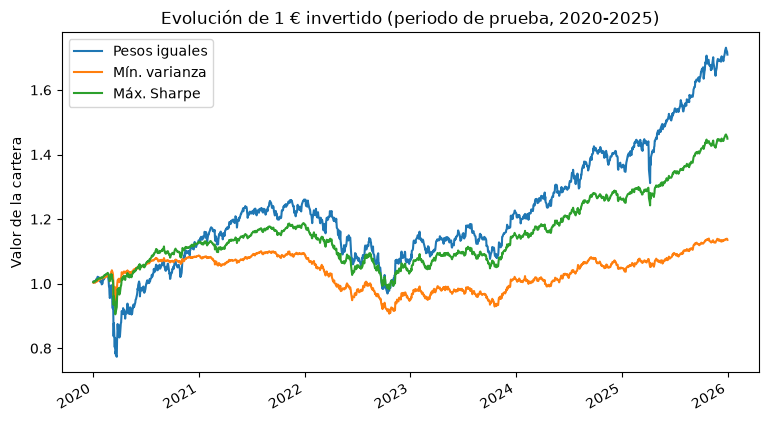

In [4]:
crecimiento = (1 + rent_diaria).cumprod()

fig, ax = plt.subplots(figsize=(9, 5))
crecimiento.plot(ax=ax)
ax.set_title("Evolución de 1 € invertido (periodo de prueba, 2020-2025)")
ax.set_ylabel("Valor de la cartera")
ax.set_xlabel("")
plt.show()

In [5]:
ent_activos = resumen_activos(entrenamiento, rf_ent)      # lo que VE el optimizador
prueba_activos = resumen_activos(prueba, rf_prueba)       # lo que pasa DESPUÉS

comparacion_activos = pd.concat(
    [ent_activos.add_suffix(" (ent.)"), prueba_activos.add_suffix(" (prueba)")],
    axis=1,
)
# Peso que el optimizador dio a cada activo en la cartera de máximo Sharpe
comparacion_activos["Peso máx. Sharpe"] = carteras["Máx. Sharpe"]

comparacion_activos.round(3)

,Rentabilidad (ent.),Volatilidad (ent.),Sharpe (ent.),Rentabilidad (prueba),Volatilidad (prueba),Sharpe (prueba),Peso máx. Sharpe
AGG,0.036,0.029,0.787,0.011,0.065,-0.272,0.656
EEM,0.129,0.181,0.639,0.079,0.217,0.233,0.000
EFA,0.085,0.134,0.535,0.103,0.194,0.384,0.000
GLD,0.090,0.121,0.629,0.184,0.163,0.951,0.100
SPY,0.146,0.129,1.031,0.162,0.207,0.642,0.244
VNQ,0.094,0.141,0.571,0.060,0.243,0.129,0.000


Lo que veía el optimizador frente a lo que pasó

Esta tabla pone en la misma fila el Sharpe de cada activo en el entrenamiento (2016-2019), el peso que recibió en la cartera de máximo Sharpe y su Sharpe en la prueba (2020-2025).

AGG es el caso más claro: con un Sharpe de 0,79 en el entrenamiento recibió el 65,6 % de la cartera, y en la prueba su Sharpe fue -0,27. El optimizador no se equivocó con los datos que tenía; los datos del entrenamiento simplemente no anticipaban el cambio de los tipos de interés.

### Conclusiones

- **Con esta partición, la cartera de máximo Sharpe no supera a los pesos iguales** (Sharpe 0,47 frente a 0,50, y menos rentabilidad).
- **El resultado depende de la fecha de corte.** Con entrenamiento 2016-2022 y prueba 2023-2025, el máximo Sharpe ganaba claramente; con 2016-2019 y 2020-2025, no. Una sola partición no basta para validar una estrategia.
- **Los pesos óptimos son inestables.** Cambian mucho según el periodo de entrenamiento, porque Markowitz amplifica los errores de estimación de las rentabilidades esperadas. Los pesos iguales, sin optimizar, resultan más robustos.

**Limitaciones:**
- Solo comparo dos particiones y los periodos de prueba son cortos.
- Se reequilibra a los pesos objetivo cada día y no se descuentan costes de transacción.
- Los pesos se calculan una sola vez, sin volver a optimizar durante la prueba.
- Es un ejercicio con datos pasados, no una recomendación de inversión.

**Posibles mejoras:** limitar el peso máximo por activo, reoptimizar periódicamente (ventana móvil) o suavizar las estimaciones.

In [6]:
pd.DataFrame({
    "Entrena 2016-2019 / Prueba 2020-2025": backtest(rentabilidades, tbill, "2019", "2020", "2025"),
    "Entrena 2016-2022 / Prueba 2023-2025": backtest(rentabilidades, tbill, "2022", "2023", "2025"),
}).T.round(2)

,Pesos iguales,Mín. varianza,Máx. Sharpe (Z = 1.0)
Entrena 2016-2019 / Prueba 2020-2025,0.50,-0.08,0.47
Entrena 2016-2022 / Prueba 2023-2025,1.09,0.10,1.81


El mismo método da resultados opuestos según dónde se corte la muestra: con 2023-2025 como prueba el máximo Sharpe gana de largo, y con 2020-2025 no. Por eso un backtest con una sola partición no demuestra que una estrategia funcione.